  TRANSFORMER + KD + QUANTIZATION PIPELINE

📂 Loading preprocessed data from: /content/drive/MyDrive/CSE499A/residential_wearable_data/outputs/preprocessed_data.pkl
✓ Shape:    (1586880, 24)
✓ Features: 20
✓ Classes:  82

🖥️  Device: cuda

  PREPROCESSING

🔧 Creating windows...
   Window: 444 rows | Stride: 222
   ✓ Windows shape: (7147, 444, 20)

🔧 Imputing & scaling...

🔧 Encoding labels...
   ✓ 82 classes

🔧 Splitting...
   ✓ Train:  5,359
   ✓ Val:      715
   ✓ Test:   1,073

  DATA SHAPES FOR TRANSFORMERS
Sequence length: 444
Num features:    20
Num classes:     82

📊 Teacher parameters: 243,826
📊 Student parameters: 77,906 (0.32x of teacher)

  TRAINING TEACHER TRANSFORMER

🚀 Training Teacher (CE)...
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


   Epoch  1/25 | Loss: 3.8549 | F1: 0.0609 | Acc: 0.1273
   Epoch  5/25 | Loss: 3.2415 | F1: 0.1140 | Acc: 0.1538
   Epoch 10/25 | Loss: 2.8630 | F1: 0.1710 | Acc: 0.1944
   Epoch 15/25 | Loss: 2.5711 | F1: 0.1977 | Acc: 0.2336
   Epoch 20/25 | Loss: 2.3153 | F1: 0.2276 | Acc: 0.2503
   >>> LR reduced: 0.001000 → 0.000500
   Epoch 25/25 | Loss: 1.9681 | F1: 0.2650 | Acc: 0.2825
----------------------------------------------------------------------
✅ Best Val F1 (Teacher): 0.2682

🎯 Teacher Test: F1=0.2897, Acc=0.3020

  TRAINING STUDENT TRANSFORMER (KD)

🚀 Training Student with Knowledge Distillation...
----------------------------------------------------------------------
   Epoch  1/25 | Loss: 4.3208 | F1: 0.0443 | Acc: 0.1175
   Epoch  5/25 | Loss: 2.5302 | F1: 0.1070 | Acc: 0.1524
   Epoch 10/25 | Loss: 2.0869 | F1: 0.1550 | Acc: 0.1916
   Epoch 15/25 | Loss: 1.8558 | F1: 0.2048 | Acc: 0.2378
   Epoch 20/25 | Loss: 1.7019 | F1: 0.2313 | Acc: 0.2545
   Epoch 25/25 | Loss: 1.6189 | F

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/torch/nn/


🎯 Quantized Student INT8 Results (head + input_proj only)
F1  = 0.2227
ACC = 0.2544

📊 Generating plots...


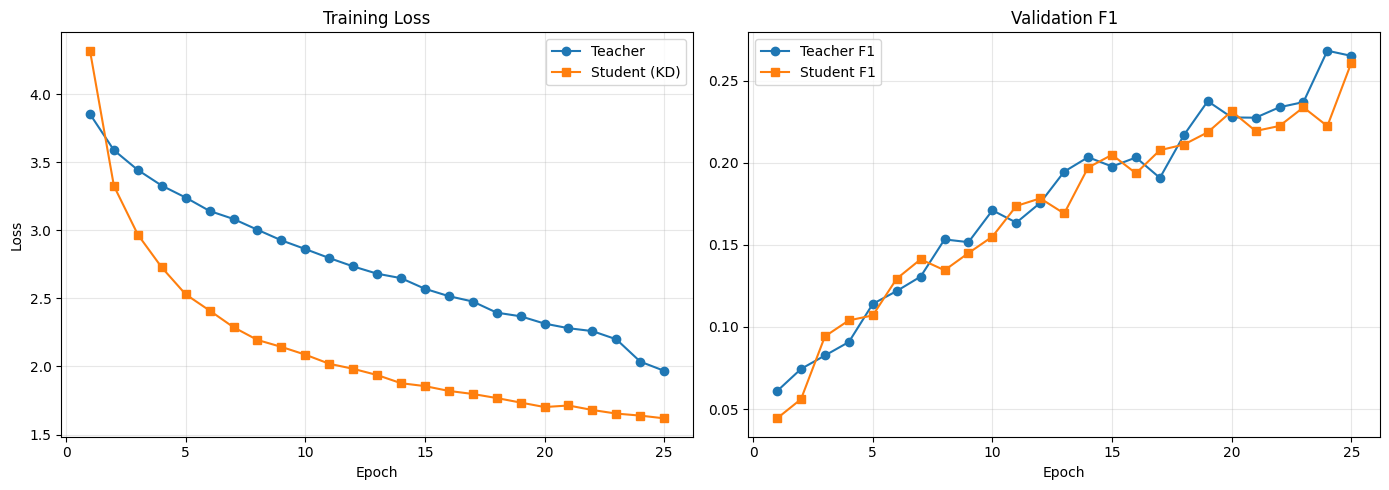

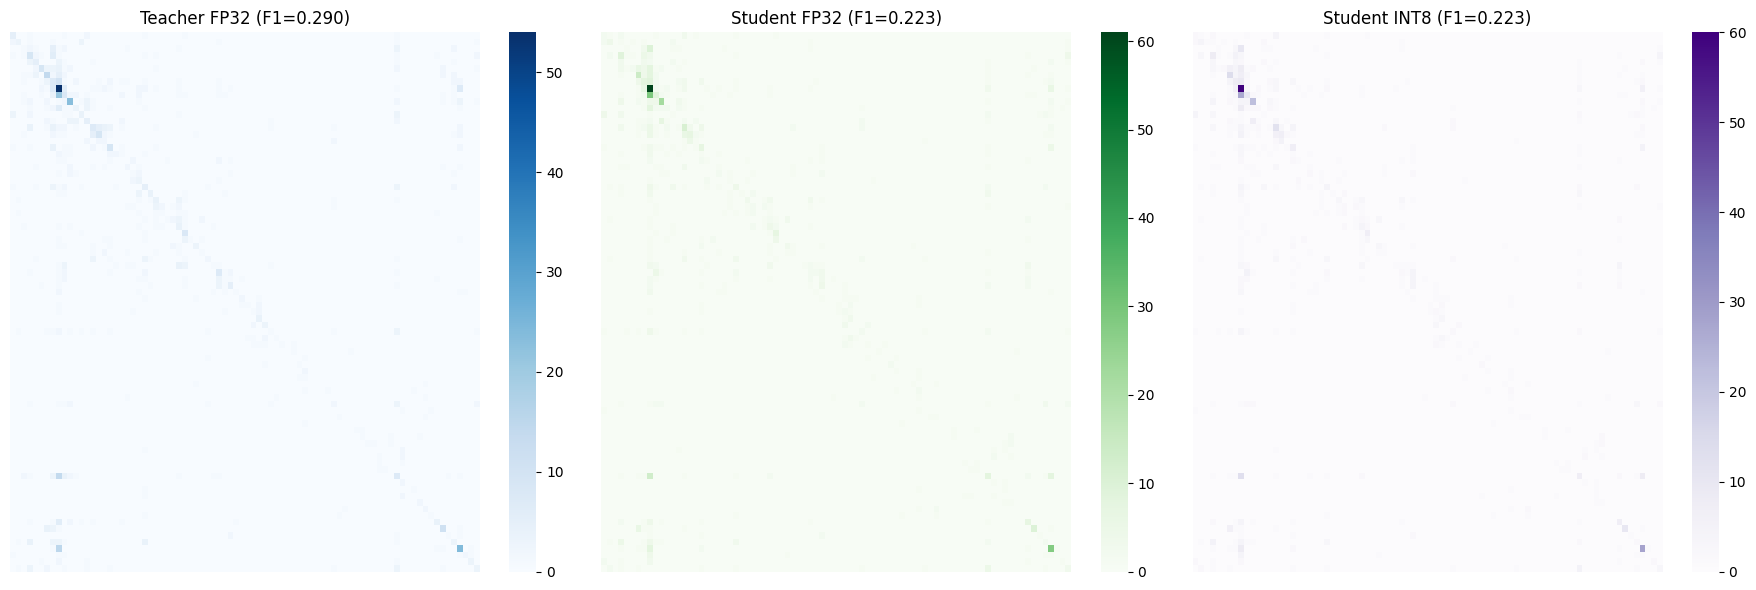


  ✅ FULL TRANSFORMER + KD + QUANTIZATION PIPELINE COMPLETE!

Model              F1       Acc      Size (KB) 
--------------------------------------------------
Teacher FP32       0.2897   0.3020   968.5     
Student FP32       0.2229   0.2544   316.1     
Student INT8       0.2227   0.2544   289.8     

💾 Saving models...
✅ All models saved successfully!

📁 All outputs saved to: /content/drive/MyDrive/CSE499A/residential_wearable_data/outputs


In [19]:
# ======================================================================
# TRANSFORMER + KNOWLEDGE DISTILLATION + QUANTIZATION (ONE-CELL PIPELINE)
# ======================================================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime

print("="*70)
print("  TRANSFORMER + KD + QUANTIZATION PIPELINE")
print("="*70)

# ----------------------------------------------------------------------
# 1) LOAD PREPROCESSED DATA (from PART 1)
# ----------------------------------------------------------------------

OUTPUT_DIR = "/content/drive/MyDrive/CSE499A/residential_wearable_data/outputs"
preprocessed_path = os.path.join(OUTPUT_DIR, "preprocessed_data.pkl")

if not os.path.exists(preprocessed_path):
    raise FileNotFoundError("❌ Run PART 1 first to generate preprocessed_data.pkl")

print(f"\n📂 Loading preprocessed data from: {preprocessed_path}")
df = pd.read_pickle(preprocessed_path)

label_col = "tag"
time_col = "timestamp" if "timestamp" in df.columns else None
feature_cols = [
    c for c in df.columns
    if np.issubdtype(df[c].dtype, np.number)
    and c not in [label_col, time_col, "house_id", "experiment"]
]

print(f"✓ Shape:    {df.shape}")
print(f"✓ Features: {len(feature_cols)}")
print(f"✓ Classes:  {df[label_col].nunique()}")

# ----------------------------------------------------------------------
# 2) CONFIG
# ----------------------------------------------------------------------

TRAIN_CFG = {
    "WINDOW_SECONDS": 4,
    "WINDOW_STRIDE": 2,
    "RANDOM_SEED": 42,
    "BATCH_SIZE": 64,
    "NUM_EPOCHS": 25,
    "LEARNING_RATE": 1e-3,
    "TEST_SIZE": 0.15,
    "VAL_SIZE": 0.10,

    # KD
    "KD_ALPHA": 0.5,          # weight for distillation loss
    "KD_TEMPERATURE": 3.0,    # temperature T
}

# Teacher model hyperparameters (larger)
TEACHER_MODEL_CFG = {
    "D_MODEL": 96,
    "N_HEAD": 4,
    "NUM_LAYERS": 3,
    "DIM_FEEDFORWARD": 192,
    "DROPOUT": 0.2,
}

# Student model hyperparameters (smaller)
STUDENT_MODEL_CFG = {
    "D_MODEL": 64,
    "N_HEAD": 4,
    "NUM_LAYERS": 2,
    "DIM_FEEDFORWARD": 128,
    "DROPOUT": 0.2,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Device: {DEVICE}")

# ----------------------------------------------------------------------
# 3) PREPROCESSING (windowing, imputing, scaling, splitting)
# ----------------------------------------------------------------------

def make_windows_from_dataframe(df, feature_cols, label_col, time_col=None,
                                window_seconds=4, stride_seconds=2):
    """
    Turns the sample stream into sliding windows using either timestamps
    (if available) or simple row-based windows.
    """
    X = df[feature_cols].values
    y = df[label_col].values

    if time_col and time_col in df.columns:
        times = pd.to_datetime(df[time_col], errors="coerce")
        secs = (times - times.iloc[0]).dt.total_seconds().values

        diffs = np.diff(secs)
        diffs = diffs[diffs > 0]
        median_dt = np.median(diffs) if len(diffs) > 0 else 0.2
        sampling_hz = 1.0 / median_dt if median_dt > 0 else 1.0

        window_rows = max(1, int(round(window_seconds * sampling_hz)))
        stride_rows = max(1, int(round(stride_seconds * sampling_hz)))
    else:
        window_rows = window_seconds if isinstance(window_seconds, int) else 4
        stride_rows = max(1, window_rows // 2)

    print(f"   Window: {window_rows} rows | Stride: {stride_rows}")

    Xw, yw = [], []
    for start in range(0, len(X) - window_rows + 1, stride_rows):
        end = start + window_rows
        Xw.append(X[start:end])
        labels_window = y[start:end]
        u, c = np.unique(labels_window, return_counts=True)
        yw.append(u[np.argmax(c)])

    return np.array(Xw), np.array(yw), window_rows


def preprocess_pipeline(df, feature_cols, label_col, time_col, cfg):
    print("\n" + "="*70)
    print("  PREPROCESSING")
    print("="*70)

    # 1) Windowing
    print("\n🔧 Creating windows...")
    Xw, yw, wrows = make_windows_from_dataframe(
        df, feature_cols, label_col, time_col,
        cfg["WINDOW_SECONDS"], cfg["WINDOW_STRIDE"]
    )
    print(f"   ✓ Windows shape: {Xw.shape}")

    n_windows, wlen, nfeat = Xw.shape

    # 2) Impute & scale
    print("\n🔧 Imputing & scaling...")
    Xflat = Xw.reshape(n_windows * wlen, nfeat)

    imputer = SimpleImputer(strategy="constant", fill_value=-120)
    Xflat = imputer.fit_transform(Xflat)

    scaler = StandardScaler()
    Xflat = scaler.fit_transform(Xflat)

    Xw_scaled = Xflat.reshape(n_windows, wlen, nfeat)

    # 3) Encode labels
    print("\n🔧 Encoding labels...")
    le = LabelEncoder()
    yw_enc = le.fit_transform(yw.astype(str))
    print(f"   ✓ {len(le.classes_)} classes")

    # 4) Train / Val / Test split
    print("\n🔧 Splitting...")
    X_temp, X_test, y_temp, y_test = train_test_split(
        Xw_scaled, yw_enc,
        test_size=cfg["TEST_SIZE"],
        random_state=cfg["RANDOM_SEED"],
        stratify=yw_enc
    )

    val_size_rel = cfg["VAL_SIZE"] / (1.0 - cfg["TEST_SIZE"])
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_size_rel,
        random_state=cfg["RANDOM_SEED"],
        stratify=y_temp
    )

    print(f"   ✓ Train: {X_train.shape[0]:>6,}")
    print(f"   ✓ Val:   {X_val.shape[0]:>6,}")
    print(f"   ✓ Test:  {X_test.shape[0]:>6,}")

    return {
        "X_train": X_train, "y_train": y_train,
        "X_val": X_val, "y_val": y_val,
        "X_test": X_test, "y_test": y_test,
        "scaler": scaler,
        "label_encoder": le,
        "window_rows": wrows,
    }

prep = preprocess_pipeline(df, feature_cols, label_col, time_col, TRAIN_CFG)

# ----------------------------------------------------------------------
# 4) DATASET & DATALOADERS
# ----------------------------------------------------------------------

class WindowedDataset(Dataset):
    """
    Returns x: (seq_len, n_features)  and y: class index
    for Transformer.
    """
    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx])  # (T, F)
        y = torch.tensor(self.y[idx])
        return x, y

train_ds = WindowedDataset(prep["X_train"], prep["y_train"])
val_ds   = WindowedDataset(prep["X_val"], prep["y_val"])
test_ds  = WindowedDataset(prep["X_test"], prep["y_test"])

train_loader = DataLoader(train_ds, batch_size=TRAIN_CFG["BATCH_SIZE"], shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=TRAIN_CFG["BATCH_SIZE"])
test_loader  = DataLoader(test_ds,  batch_size=TRAIN_CFG["BATCH_SIZE"])

seq_len    = prep["window_rows"]
n_features = prep["X_train"].shape[2]
num_classes = len(prep["label_encoder"].classes_)

print("\n" + "="*70)
print("  DATA SHAPES FOR TRANSFORMERS")
print("="*70)
print(f"Sequence length: {seq_len}")
print(f"Num features:    {n_features}")
print(f"Num classes:     {num_classes}")

# ----------------------------------------------------------------------
# 5) TRANSFORMER MODELS (teacher & student)
# ----------------------------------------------------------------------

class RSSITransformer(nn.Module):
    def __init__(self, n_features, num_classes, model_cfg):
        super().__init__()
        d_model = model_cfg["D_MODEL"]
        nhead = model_cfg["N_HEAD"]
        num_layers = model_cfg["NUM_LAYERS"]
        dim_ff = model_cfg["DIM_FEEDFORWARD"]
        dropout = model_cfg["DROPOUT"]

        self.input_proj = nn.Linear(n_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation="relu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x):
        # x: (B, T, n_features)
        x = self.input_proj(x)   # (B, T, d_model)
        h = self.encoder(x)      # (B, T, d_model)
        h = h.mean(dim=1)        # global average pooling over time
        logits = self.head(h)    # (B, num_classes)
        return logits

teacher_model = RSSITransformer(n_features, num_classes, TEACHER_MODEL_CFG).to(DEVICE)
student_model = RSSITransformer(n_features, num_classes, STUDENT_MODEL_CFG).to(DEVICE)

teacher_params = sum(p.numel() for p in teacher_model.parameters())
student_params = sum(p.numel() for p in student_model.parameters())

print(f"\n📊 Teacher parameters: {teacher_params:,}")
print(f"📊 Student parameters: {student_params:,} ({student_params/teacher_params:.2f}x of teacher)")

# ----------------------------------------------------------------------
# 6) TRAINING HELPERS
# ----------------------------------------------------------------------

def eval_model(model, dataloader, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in dataloader:
            Xb = Xb.to(device)
            logits = model(Xb)
            p = torch.argmax(logits, dim=1).cpu().numpy()
            preds.extend(p.tolist())
            trues.extend(yb.numpy().tolist())
    return np.array(trues), np.array(preds)

def train_epoch_ce(model, dataloader, criterion, optimizer, device):
    """Standard CE training epoch."""
    model.train()
    running_loss = 0.0
    for Xb, yb in dataloader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * Xb.size(0)
    return running_loss / len(dataloader.dataset)

def train_and_validate_ce(model, train_loader, val_loader, device, cfg, model_name="Model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["LEARNING_RATE"], weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_val_f1 = -1.0
    best_state = None
    history = {"train_loss": [], "val_f1": [], "val_acc": []}

    print(f"\n🚀 Training {model_name} (CE)...")
    print("-" * 70)

    for epoch in range(cfg["NUM_EPOCHS"]):
        loss = train_epoch_ce(model, train_loader, criterion, optimizer, device)
        y_true, y_pred = eval_model(model, val_loader, device)
        val_f1 = f1_score(y_true, y_pred, average="weighted")
        val_acc = accuracy_score(y_true, y_pred)

        history["train_loss"].append(loss)
        history["val_f1"].append(val_f1)
        history["val_acc"].append(val_acc)

        old_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_f1)
        new_lr = optimizer.param_groups[0]["lr"]
        if new_lr != old_lr:
            print(f"   >>> LR reduced: {old_lr:.6f} → {new_lr:.6f}")

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"   Epoch {epoch+1:2d}/{cfg['NUM_EPOCHS']} | "
                  f"Loss: {loss:.4f} | F1: {val_f1:.4f} | Acc: {val_acc:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)

    print("-" * 70)
    print(f"✅ Best Val F1 ({model_name}): {best_val_f1:.4f}")
    return model, history

# ---- KD training ----

def kd_loss_fn(student_logits, teacher_logits, targets, T, alpha):
    """
    Standard KD loss:
    (1-alpha) * CE(student, y) + alpha * T^2 * KL(student/T, teacher/T)
    """
    ce = nn.CrossEntropyLoss()
    log_student = nn.functional.log_softmax(student_logits / T, dim=1)
    teacher_soft = nn.functional.softmax(teacher_logits / T, dim=1)
    kd = nn.functional.kl_div(log_student, teacher_soft, reduction="batchmean") * (T * T)
    hard_loss = ce(student_logits, targets)
    return (1 - alpha) * hard_loss + alpha * kd

def train_and_validate_kd(teacher, student, train_loader, val_loader, device, cfg):
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False

    optimizer = torch.optim.Adam(student.parameters(), lr=cfg["LEARNING_RATE"], weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    alpha = cfg["KD_ALPHA"]
    T = cfg["KD_TEMPERATURE"]

    best_val_f1 = -1.0
    best_state = None
    history = {"train_loss": [], "val_f1": [], "val_acc": []}

    print("\n🚀 Training Student with Knowledge Distillation...")
    print("-" * 70)

    for epoch in range(cfg["NUM_EPOCHS"]):
        student.train()
        running_loss = 0.0

        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()

            with torch.no_grad():
                teacher_logits = teacher(Xb)

            student_logits = student(Xb)
            loss = kd_loss_fn(student_logits, teacher_logits, yb, T, alpha)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * Xb.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)

        # Validation
        y_true, y_pred = eval_model(student, val_loader, device)
        val_f1 = f1_score(y_true, y_pred, average="weighted")
        val_acc = accuracy_score(y_true, y_pred)

        history["train_loss"].append(epoch_loss)
        history["val_f1"].append(val_f1)
        history["val_acc"].append(val_acc)

        old_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(val_f1)
        new_lr = optimizer.param_groups[0]["lr"]
        if new_lr != old_lr:
            print(f"   >>> LR reduced: {old_lr:.6f} → {new_lr:.6f}")

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"   Epoch {epoch+1:2d}/{cfg['NUM_EPOCHS']} | "
                  f"Loss: {epoch_loss:.4f} | F1: {val_f1:.4f} | Acc: {val_acc:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = student.state_dict()

    if best_state is not None:
        student.load_state_dict(best_state)

    print("-" * 70)
    print(f"✅ Best Val F1 (Student KD): {best_val_f1:.4f}")
    return student, history

# ----------------------------------------------------------------------
# 7) TRAIN TEACHER (CE) AND STUDENT (KD)
# ----------------------------------------------------------------------

print("\n" + "="*70)
print("  TRAINING TEACHER TRANSFORMER")
print("="*70)

teacher_model, history_teacher = train_and_validate_ce(
    teacher_model, train_loader, val_loader, DEVICE, TRAIN_CFG, model_name="Teacher"
)

y_true_teacher_test, y_pred_teacher_test = eval_model(teacher_model, test_loader, DEVICE)
f1_teacher = f1_score(y_true_teacher_test, y_pred_teacher_test, average="weighted")
acc_teacher = accuracy_score(y_true_teacher_test, y_pred_teacher_test)
print(f"\n🎯 Teacher Test: F1={f1_teacher:.4f}, Acc={acc_teacher:.4f}")

print("\n" + "="*70)
print("  TRAINING STUDENT TRANSFORMER (KD)")
print("="*70)

student_model, history_student = train_and_validate_kd(
    teacher_model, student_model, train_loader, val_loader, DEVICE, TRAIN_CFG
)

y_true_student_test, y_pred_student_test = eval_model(student_model, test_loader, DEVICE)
f1_student = f1_score(y_true_student_test, y_pred_student_test, average="weighted")
acc_student = accuracy_score(y_true_student_test, y_pred_student_test)
print(f"\n🎯 Student (KD) Test: F1={f1_student:.4f}, Acc={acc_student:.4f}")

print("\nClassification report (Student FP32):\n")
print(classification_report(
    y_true_student_test,
    y_pred_student_test,
    target_names=prep["label_encoder"].classes_
))

# ----------------------------------------------------------------------
# 8) CALCULATE MODEL SIZES (FP32)
# ----------------------------------------------------------------------

def get_model_size_kb(model):
    """Calculate model size in KB"""
    import tempfile
    temp_path = tempfile.NamedTemporaryFile(delete=False).name
    torch.save(model.state_dict(), temp_path)
    size_kb = os.path.getsize(temp_path) / 1024
    os.remove(temp_path)
    return size_kb

size_teacher_fp32 = get_model_size_kb(teacher_model)
size_student_fp32 = get_model_size_kb(student_model)

print(f"\n📦 Teacher FP32 size: {size_teacher_fp32:.2f} KB")
print(f"📦 Student FP32 size: {size_student_fp32:.2f} KB")


# ----------------------------------------------------------------------
# 9) QUANTIZATION (Dynamic INT8 of student model)
# ----------------------------------------------------------------------

# ----------------------------------------------------------------------
# 9) QUANTIZATION (Dynamic INT8 of Student model – head + input_proj)
# ----------------------------------------------------------------------

import torch.quantization as tq
import copy

print("\n" + "="*70)
print("  FIXED QUANTIZATION (Dynamic INT8 for Student Transformer)")
print("="*70)

# 1. Make a CPU copy of the trained student (FP32 weights)
student_cpu = RSSITransformer(
    n_features,
    num_classes,
    STUDENT_MODEL_CFG
).to("cpu")

student_cpu.load_state_dict(student_model.state_dict())
student_cpu.eval()
print("✓ Student model copied to CPU.")

# 2. Create a *separate* copy we will partially quantize
quantized_student = copy.deepcopy(student_cpu)

# 3. Apply dynamic INT8 quantization ONLY to:
#    - input_proj (Linear)
#    - head (all Linear layers inside the head Sequential)
print("✓ Applying safe INT8 dynamic quantization (Linear layers only)...")

quantized_student.input_proj = tq.quantize_dynamic(
    quantized_student.input_proj,
    {nn.Linear},
    dtype=torch.qint8
)

quantized_student.head = tq.quantize_dynamic(
    quantized_student.head,
    {nn.Linear},
    dtype=torch.qint8
)

print("✓ INT8 quantization completed successfully (no encoder quantization).")

# 4. Calculate model sizes
size_student_fp32 = get_model_size_kb(student_model)
size_student_int8 = get_model_size_kb(quantized_student)
compression_ratio = size_student_fp32 / size_student_int8

print(f"\n📦 Student FP32 size: {size_student_fp32:.2f} KB")
print(f"📦 Student INT8 size: {size_student_int8:.2f} KB")
print(f"🗜️  Compression ratio: {compression_ratio:.2f}x smaller")

# 5. Evaluate the quantized model on test set (CPU)
print("\n🔍 Evaluating INT8 quantized student model...")

quantized_student.eval()
y_pred_student_q = []
y_true_student_q = prep["y_test"]

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.cpu()                 # keep inputs on CPU
        logits = quantized_student(xb)
        preds = torch.argmax(logits, dim=1).numpy()
        y_pred_student_q.extend(preds)

y_pred_student_q = np.array(y_pred_student_q)

f1_student_q = f1_score(y_true_student_q, y_pred_student_q, average="weighted")
acc_student_q = accuracy_score(y_true_student_q, y_pred_student_q)

print("\n🎯 Quantized Student INT8 Results (head + input_proj only)")
print(f"F1  = {f1_student_q:.4f}")
print(f"ACC = {acc_student_q:.4f}")
print("="*70)


# ----------------------------------------------------------------------
# 10) VISUALIZATIONS (training curves + confusion matrices)
# ----------------------------------------------------------------------

print("\n📊 Generating plots...")

epochs = range(1, TRAIN_CFG["NUM_EPOCHS"] + 1)
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, history_teacher["train_loss"], label="Teacher", marker="o")
plt.plot(epochs, history_student["train_loss"], label="Student (KD)", marker="s")
plt.title("Training Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(alpha=0.3); plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history_teacher["val_f1"], label="Teacher F1", marker="o")
plt.plot(epochs, history_student["val_f1"], label="Student F1", marker="s")
plt.title("Validation F1")
plt.xlabel("Epoch"); plt.grid(alpha=0.3); plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "kd_transformer_training_history.png"), dpi=150)
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18,6))

cm_teacher = confusion_matrix(y_true_teacher_test, y_pred_teacher_test)
sns.heatmap(cm_teacher, ax=axes[0], cmap="Blues",
            xticklabels=False, yticklabels=False)
axes[0].set_title(f"Teacher FP32 (F1={f1_teacher:.3f})")

cm_student = confusion_matrix(y_true_student_test, y_pred_student_test)
sns.heatmap(cm_student, ax=axes[1], cmap="Greens",
            xticklabels=False, yticklabels=False)
axes[1].set_title(f"Student FP32 (F1={f1_student:.3f})")

cm_student_q = confusion_matrix(y_true_student_q, y_pred_student_q)
sns.heatmap(cm_student_q, ax=axes[2], cmap="Purples",
            xticklabels=False, yticklabels=False)
axes[2].set_title(f"Student INT8 (F1={f1_student_q:.3f})")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "kd_transformer_confusion_matrices.png"), dpi=150)
plt.show()

# ----------------------------------------------------------------------
# 11) SAVE RESULTS JSON
# ----------------------------------------------------------------------

def convert_to_native(obj):
    if isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_native(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_native(item) for item in obj]
    return obj

results = {
    "timestamp": datetime.now().isoformat(),
    "train_cfg": TRAIN_CFG,
    "teacher_model_cfg": TEACHER_MODEL_CFG,
    "student_model_cfg": STUDENT_MODEL_CFG,
    "teacher": {
        "params": int(teacher_params),
        "fp32": {
            "f1": float(f1_teacher),
            "acc": float(acc_teacher),
            "size_kb": float(size_teacher_fp32),
        },
    },
    "student": {
        "params": int(student_params),
        "fp32": {
            "f1": float(f1_student),
            "acc": float(acc_student),
            "size_kb": float(size_student_fp32),
        },
        "int8_dynamic": {
            "f1": float(f1_student_q),
            "acc": float(acc_student_q),
            "size_kb": float(size_student_int8),
            "compression_ratio": float(compression_ratio),
        },
    },
}

results = convert_to_native(results)
with open(os.path.join(OUTPUT_DIR, "transformer_kd_results.json"), "w") as f:
    json.dump(results, f, indent=2)

print("\n" + "="*70)
print("  ✅ FULL TRANSFORMER + KD + QUANTIZATION PIPELINE COMPLETE!")
print("="*70)
print(f"\n{'Model':<18} {'F1':<8} {'Acc':<8} {'Size (KB)':<10}")
print("-"*50)
print(f"{'Teacher FP32':<18} {f1_teacher:<8.4f} {acc_teacher:<8.4f} {size_teacher_fp32:<10.1f}")
print(f"{'Student FP32':<18} {f1_student:<8.4f} {acc_student:<8.4f} {size_student_fp32:<10.1f}")
print(f"{'Student INT8':<18} {f1_student_q:<8.4f} {acc_student_q:<8.4f} {size_student_int8:<10.1f}")
print("="*70)

# ----------------------------------------------------------------------
# 12) SAVE MODELS
# ----------------------------------------------------------------------

print("\n💾 Saving models...")
torch.save(teacher_model.state_dict(), os.path.join(OUTPUT_DIR, "teacher_model.pth"))
torch.save(student_model.state_dict(), os.path.join(OUTPUT_DIR, "student_model.pth"))
torch.save(quantized_student.state_dict(), os.path.join(OUTPUT_DIR, "student_quantized.pth"))

print("✅ All models saved successfully!")
print(f"\n📁 All outputs saved to: {OUTPUT_DIR}")
